# Project: Urban Heat Island & Green Space Analysis

-  *Do neighborhoods with more green space stay cooler in summer?*
- *And which neighborhoods are most heat-exposed?*

In [1]:
ntatype_mapping = {
    0:"Residential",
    5:"Rikers Island",
    6:"Other Special Areas",
    7:"Cemetery",
    8:"Airport",
    9:"Park"
    }

In [2]:
import sys
sys.path.append('..')

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray
import numpy as np
import xarray as xr
from rasterstats import zonal_stats, point_query
from geocube.api.core import make_geocube
import pandas as pd
import seaborn
import plotly.graph_objects as go
import plotly.express as px

In [79]:
df_lst_ndvi = pd.read_parquet('../data/processed/20220806_20220817/lst_ndvi.parquet.gzip')
gdf_nb_temperature = gpd.read_file('../data/processed/20220806_20220817/temperature.geojson')
gdf_nb_temperature = gdf_nb_temperature.dropna()
scene = '20190729_20200827'

In [80]:

df_lst_mean = gdf_nb_temperature.sort_values(by='lst_mean')[ ['ntatype','borocode','boroname','ntaname','nb_id', 'lst_mean', 'ndvi_mean']]
df_lst_min_max_nb = pd.concat([df_lst_mean[:5], df_lst_mean[-5:]])


In [85]:
df = df_lst_min_max_nb.sort_values('lst_mean')

fig = go.Figure(go.Bar(
    x=df[value_col],
    y=df[label_col],
    orientation="h",
    marker=dict(
        color=df['lst_mean'],
        colorscale=colorscale,
        colorbar=dict(title=dict(text=legend_name)),
        cmin=20,
        cmax=60,
    ),
    customdata=df[["boroname", "ndvi_mean", "ntatype"]],
    hovertemplate=(
        "<b>%{y}</b> (%{customdata[0]})<br>"
        "Type: %{customdata[2]}<br>"
        "%{x:.1f}°C<br>"
        "NDVI: %{customdata[1]:.2f}<extra></extra>"
    ),
))

fig.update_layout(
    margin=dict(t=50, b=40, l=10, r=20),
    title=dict(text=title),
    xaxis_title=legend_name,
    yaxis_title=None,
    template="plotly_white",
    bargap=0.35, 
    barcornerradius=30,
    height=800,

)
fig.update_xaxes(range=[20, 60])



In [86]:
pearson_coeff = df_lst_ndvi['lst'].corr(df_lst_ndvi['ndvi'])
slope, intercept = np.polyfit(df_lst_ndvi["ndvi"], df_lst_ndvi["lst"], 1)

print(f"Pearson r = {pearson_coeff:.3f}")
print(f"slope = {slope:.1f} °C per 1.0 NDVI  ({slope/10:.2f} °C per 0.1 NDVI)")

Pearson r = -0.628
slope = -9.4 °C per 1.0 NDVI  (-0.94 °C per 0.1 NDVI)


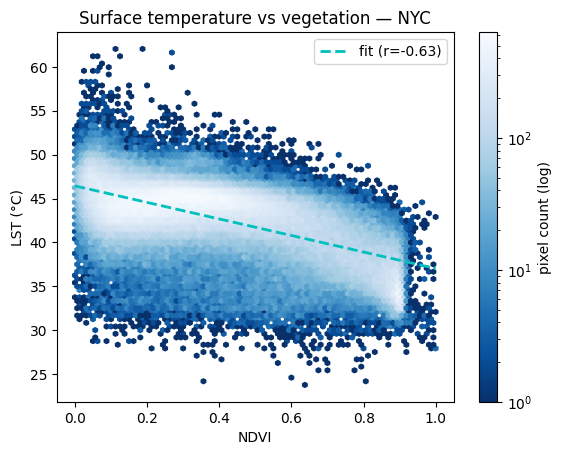

In [87]:

# scatter — but you have millions of pixels, so a raw scatter is a useless black blob.
# use hexbin (2D density) instead:
plt.hexbin(df_lst_ndvi["ndvi"], df_lst_ndvi["lst"], gridsize=80, cmap="Blues_r", mincnt=1, bins="log")
x = np.linspace(df_lst_ndvi["ndvi"].min(), df_lst_ndvi["ndvi"].max(), 100)
plt.plot(x, slope*x + intercept, "c--", lw=2, label=f"fit (r={pearson_coeff:.2f})")
plt.xlabel("NDVI"); plt.ylabel("LST (°C)")
plt.colorbar(label="pixel count (log)")
plt.legend(); plt.title("Surface temperature vs vegetation — NYC")
plt.show()


#### Answer: yes -> around 0.9 oer 0.1 ndvi. Proof (scatter + LST vs. NDVI plot)
- **slope = −9.0 °C** per NDVI unit → for every 0.1 increase in NDVI, the surface is about 0.9 °C cooler.
- **intercept ≈ 41 °C** ( NDVI = 0) → the predicted surface temperature of a fully unvegetated pixel — bare pavement/rooftop.
- r = −0.624 is the strength and direction of the linear relationship. Negative = greener is cooler. As for "good": square it — r² ≈ 0.39, meaning NDVI alone explains ~39% of the pixel-to-pixel temperature variation. For a single predictor on noisy satellite data over a whole city, that's a genuinely solid signal.

In [88]:
gdf_nb_tp_type0 = gdf_nb_temperature.loc[ gdf_nb_temperature.ntatype == '0']

#### The geography: heat beside green; they read as photo negatives of each other, which is your whole thesis in one glance.

In [89]:
df_lst_mean = gdf_nb_tp_type0.sort_values(by='lst_mean')[ ['borocode','boroname','ntaname','nb_id', 'lst_mean', 'ndvi_mean']]

<Axes: >

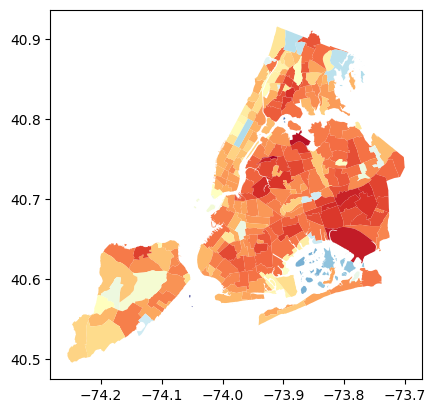

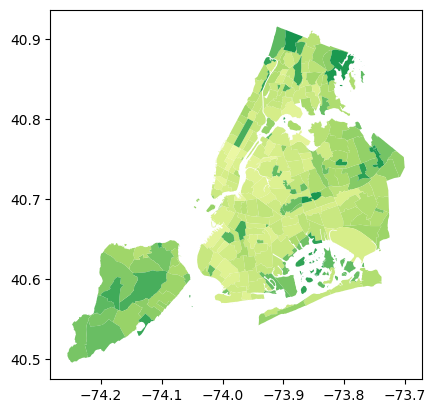

In [90]:
gdf_nb_temperature.plot(column='lst_mean', cmap="RdYlBu_r")
gdf_nb_temperature.plot(column='ndvi_mean', cmap="RdYlGn", vmin=-1, vmax=1)

#### Ranked Chart: hottest/coolest residential neighborhoods

In [91]:
gdf_nb_tp_type0.sort_values(by='lst_mean')[['boroname', 'ntaname', 'lst_mean', 'ndvi_mean'] ]

,boroname,ntaname,lst_mean,ndvi_mean
249,Staten Island,Todt Hill-Emerson Hill-Lighthouse Hill-Manor H...,38.089542,0.679108
118,Manhattan,Financial District-Battery Park City,38.690876,0.250830
79,Bronx,Highbridge,38.898048,0.333868
137,Manhattan,Upper West Side (Central),38.938747,0.310598
138,Manhattan,Upper West Side-Manhattan Valley,39.312466,0.356162
...,...,...,...,...
3,Brooklyn,East Williamsburg,46.235111,0.167253
220,Queens,Hollis,46.243671,0.333966
216,Queens,South Jamaica,46.257088,0.314232
203,Queens,South Richmond Hill,46.268311,0.206879


#### Analysis of plot + chart

- basically resiential areas are less hot when they contains or are near parks with or without waterfront and near water areas

- Todt Hill has the lowest temperature with Riverdale Spuyten Duyvil because they have higher ndvi and are classified as residential. - Todt Hill and Riverdale-Spuyten Duyvil are cool via vegetation (NDVI 0.59–0.66, exactly the green=cool story).

- areas the hottest are in queens with low ndvi (+ socioeconmic aspect to come)

- But Financial District–Battery Park City is the third coolest at 35.4 °C with an NDVI of only 0.19 — barely any greenery. That's a clean counterexample inside your own data: FiDi is cool because it's wrapped in water on three sides (plus harbor breeze and tall-building street shading), not because it's green. So your instinct about "parks with or without waterfront and near water" is correct, and FiDi is the proof that water is a distinct cooling driver NDVI can't see. Worth calling out explicitly 

#### LST vs. NDVI pixel mean per neighborhood for residential areas only

#### Heat inequality via lst_std

<Axes: >

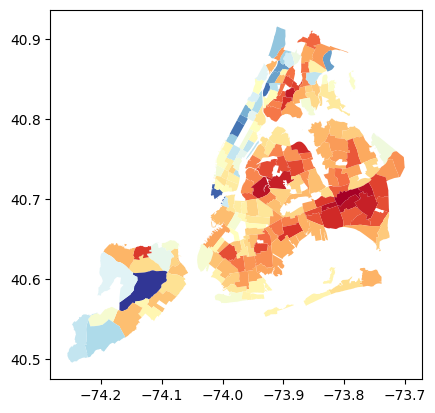

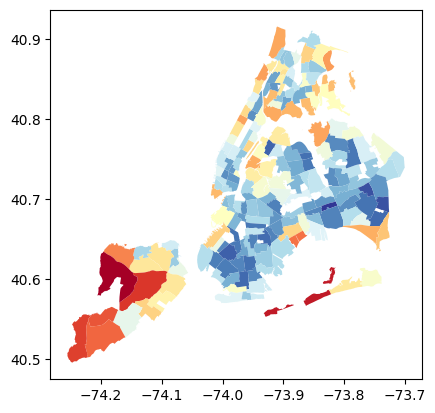

In [95]:
gdf_nb_tp_type0.plot(column='lst_mean', cmap="RdYlBu_r")
gdf_nb_tp_type0.plot(column='lst_std', cmap="RdYlBu_r")

#### Synthesis: heat risk.
 neighborhoods that are simultaneously high lst_mean and low ndvi_mean are your priority zones

In [103]:
df_inequality = gdf_nb_tp_type0.sort_values(by=['lst_std', 'lst_mean'], ascending=[True, False])[['boroname', 'ntaname', 'lst_mean', 'lst_std','ndvi_mean',  'ndvi_std'] ]
df_inequality

,boroname,ntaname,lst_mean,lst_std,ndvi_mean,ndvi_std
203,Queens,South Richmond Hill,46.268311,0.665960,0.206879,0.096963
224,Queens,Cambria Heights,45.312042,0.831270,0.368030,0.114546
220,Queens,Hollis,46.243671,0.841356,0.333966,0.132117
39,Brooklyn,Borough Park,45.292271,0.931199,0.226861,0.124670
158,Queens,Astoria (Central),42.998241,0.956050,0.152209,0.081391
...,...,...,...,...,...,...
254,Staten Island,Arden Heights-Rossville,42.099827,3.866622,0.536666,0.238695
256,Staten Island,Tottenville-Charleston,41.009708,3.994109,0.545567,0.274326
249,Staten Island,Todt Hill-Emerson Hill-Lighthouse Hill-Manor H...,38.089542,4.059004,0.679108,0.219196
231,Queens,Breezy Point-Belle Harbor-Rockaway Park-Broad ...,42.644894,4.269075,0.285659,0.185349


Lst_std insight: 
- High-std Staten Island neighborhoods straddle forested hills/parks and developed land, so they have a big internal range — cool refuges exist. 
- The hot Queens neighborhoods have low std, meaning they're uniformly hot wall-to-wall, with nowhere to escape. That "evenly hot is worse" framing is exactly the heat-inequality story. 
- One sharpening: std alone is ambiguous (a uniformly cool place also has low std), so the signal is always std conditioned on a high mean. Low-std + high-mean = the genuinely worst case, which is precisely what you found. State it as the pair, not std by itself.

In [ ]:
gdf_nb_temperature.sort_values(by=['lst_mean'])[['boroname', 'ntatype', 'ntaname', 'lst_mean', 'lst_std','ndvi_mean',  'ndvi_std'] ].dropna()[-10:]

,boroname,ntatype,ntaname,lst_mean,lst_std,ndvi_mean,ndvi_std
175,Queens,0,Maspeth,47.721508,2.854695,0.192672,0.125683
70,Bronx,0,Melrose,47.833080,2.170148,0.262713,0.161774
233,Queens,8,LaGuardia Airport,48.004463,4.071976,0.161023,0.168138
69,Bronx,0,Mott Haven-Port Morris,48.138889,2.831154,0.225196,0.173581
204,Queens,0,Ozone Park (North),48.198776,1.233142,0.225822,0.102000
174,Queens,0,Corona,48.381313,1.273175,0.204452,0.109621
3,Brooklyn,0,East Williamsburg,48.457832,2.752316,0.157591,0.130537
100,Bronx,0,Westchester Square,48.859764,2.146464,0.204354,0.128494
71,Bronx,0,Hunts Point,49.369339,4.257739,0.151607,0.138777
162,Queens,6,Sunnyside Yards (North),50.312054,5.104694,0.100260,0.066035
